Epoch 1/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 3s 506us/step - accuracy: 0.6052 - loss: 0.9148 - val_accuracy: 0.1057 - val_loss: 1.6611
Epoch 2/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 469us/step - accuracy: 0.6384 - loss: 0.8394 - val_accuracy: 0.0985 - val_loss: 1.7373
Epoch 3/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 461us/step - accuracy: 0.6447 - loss: 0.8263 - val_accuracy: 0.1508 - val_loss: 1.7006
Epoch 4/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 493us/step - accuracy: 0.6476 - loss: 0.8183 - val_accuracy: 0.1500 - val_loss: 1.5952
Epoch 5/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 470us/step - accuracy: 0.6523 - loss: 0.8073 - val_accuracy: 0.1923 - val_loss: 1.5500
Epoch 6/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 464us/step - accuracy: 0.6540 - loss: 0.8031 - val_accuracy: 0.2414 - val_loss: 1.3925
Epoch 7/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 503us/step - accuracy: 0.6571 - loss: 0.7956 - val_accuracy: 0.3100 - val_loss: 1.2510
Epoch 8/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 469us/step - accuracy: 0.6594 -

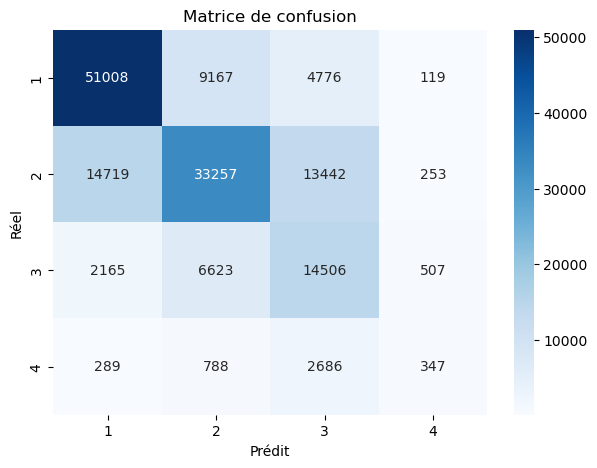

In [3]:
####################################################################
# DNN sur version v2 du feature engineering (sans communes, avec dep, agg...)
####################################################################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed_v2.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "dep" avec TargetEncoder
te = TargetEncoder()
X_train["dep_encoded"] = te.fit_transform(X_train["dep"], y_train)
X_test["dep_encoded"] = te.transform(X_test["dep"])
X_train.drop(columns="dep", inplace=True)
X_test.drop(columns="dep", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['dep_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction
y_pred = np.argmax(model.predict(X_test_processed), axis=1)

# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


Epoch 1/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 463us/step - accuracy: 0.5985 - loss: 0.9239 - val_accuracy: 0.1540 - val_loss: 1.5461
Epoch 2/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 436us/step - accuracy: 0.6360 - loss: 0.8451 - val_accuracy: 0.1594 - val_loss: 1.5019
Epoch 3/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 465us/step - accuracy: 0.6406 - loss: 0.8348 - val_accuracy: 0.1683 - val_loss: 1.5563
Epoch 4/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 472us/step - accuracy: 0.6460 - loss: 0.8225 - val_accuracy: 0.0818 - val_loss: 1.9081
Epoch 5/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 437us/step - accuracy: 0.6476 - loss: 0.8180 - val_accuracy: 0.1756 - val_loss: 1.7555
Epoch 6/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 445us/step - accuracy: 0.6512 - loss: 0.8104 - val_accuracy: 0.1997 - val_loss: 1.5060
Epoch 7/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 444us/step - accuracy: 0.6533 - loss: 0.8045 - val_accuracy: 0.1664 - val_loss: 1.5960
Epoch 8/10
4524/4524 ━━━━━━━━━━━━━━━━━━━━ 2s 436us/step - accuracy: 0.6553 -

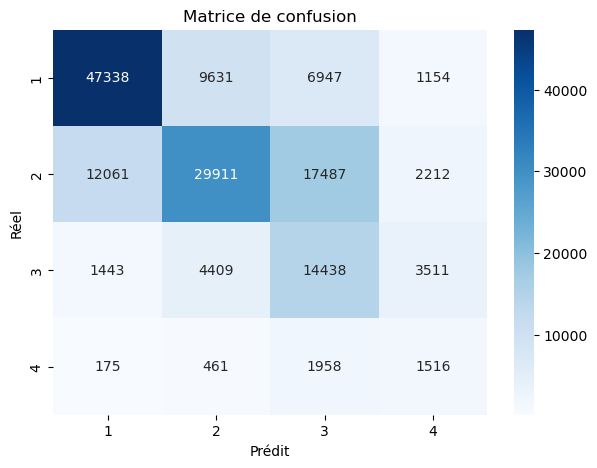

In [4]:
##################
# DNN avec SMOTETomek et ajustement de la probabilité de prédiction pour la classe 4 à 0.2 avec la version v2 du feature engineering
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed_v2.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "dep" avec TargetEncoder
te = TargetEncoder()
X_train["dep_encoded"] = te.fit_transform(X_train["dep"], y_train)
X_test["dep_encoded"] = te.transform(X_test["dep"])
X_train.drop(columns="dep", inplace=True)
X_test.drop(columns="dep", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['dep_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction

seuil_classe_4 = 0.2
classe_4_idx = 3  
y_proba = model.predict(X_test_processed)  # shape: (n_samples, n_classes)
y_pred = np.argmax(y_proba, axis=1)
y_pred[y_proba[:, classe_4_idx] >= seuil_classe_4] = classe_4_idx



# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

Epoch 1/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - accuracy: 0.4489 - loss: 1.1863 - val_accuracy: 0.0000e+00 - val_loss: 2.1062
Epoch 2/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - accuracy: 0.6087 - loss: 0.9093 - val_accuracy: 2.0274e-04 - val_loss: 2.1705
Epoch 3/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.6219 - loss: 0.8844 - val_accuracy: 3.0411e-04 - val_loss: 2.1943
Epoch 4/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.6254 - loss: 0.8811 - val_accuracy: 0.0075 - val_loss: 2.1821
Epoch 5/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - accuracy: 0.6323 - loss: 0.8605 - val_accuracy: 0.0177 - val_loss: 2.0818
Epoch 6/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.6335 - loss: 0.8561 - val_accuracy: 0.0169 - val_loss: 2.1945
Epoch 7/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - accuracy: 0.6341 - loss: 0.8554 - val_accuracy: 0.0145 - val_loss: 2.2295
Epoch 8/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - accuracy: 0.64

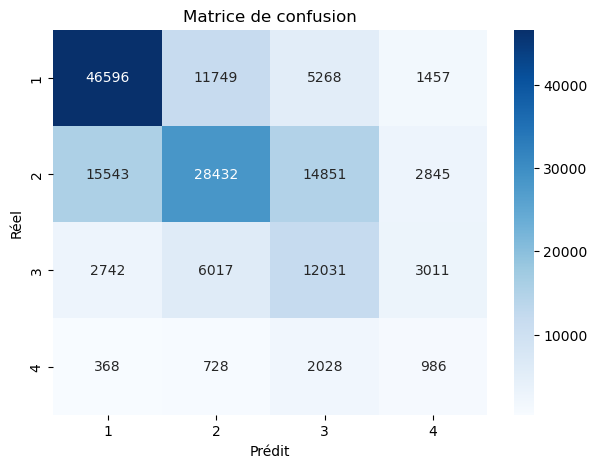

In [5]:
##################
# DNN avec undersampling et ajustement de la probabilité de prédiction pour la classe 4 à 0.2
# v2 du feature engineering (sans communes, avec dep, agg...) et one hot encoding sur toutes les colonnes (y compris dep)
# 2 couche de neurones en plus, 100 epochs 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed_v2.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
#te = TargetEncoder()
#X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
#X_test["com_encoded"] = te.transform(X_test["com"])
#X_train.drop(columns="com", inplace=True)
#X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=100, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction

seuil_classe_4 = 0.2
classe_4_idx = 3  
y_proba = model.predict(X_test_processed)  # shape: (n_samples, n_classes)
y_pred = np.argmax(y_proba, axis=1)
y_pred[y_proba[:, classe_4_idx] >= seuil_classe_4] = classe_4_idx



# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()